In [1]:
import pandas as pd
listings = pd.read_csv('../data/listings.csv.gz', compression='gzip', low_memory=False)
calendar = pd.read_csv('../data/calendar.csv.gz', compression='gzip')
reviews = pd.read_csv('../data/reviews.csv')

listings['price'] = (listings['price']
 .replace(r'[\$,]', '', regex=True)
 .astype(float))

In [2]:
missing = listings.isna().mean().sort_values(ascending=False)
missing[missing > 0].head(20)


neighborhood_overview        1.000000
host_since                   1.000000
host_response_time           1.000000
host_thumbnail_url           1.000000
host_acceptance_rate         1.000000
host_response_rate           1.000000
host_verifications           1.000000
neighbourhood                1.000000
host_total_listings_count    1.000000
host_neighbourhood           1.000000
calendar_updated             1.000000
instant_bookable             1.000000
host_about                   0.446093
host_location                0.299767
bedrooms                     0.179209
bathrooms                    0.149341
review_scores_location       0.125060
review_scores_accuracy       0.125020
last_review                  0.125020
review_scores_rating         0.125020
dtype: float64

In [13]:
# 1. Defining the threshold (keep columns that are at least 60% full)
threshold = int(len(listings) * 0.6)

# 2. Drop the columns from 'listings' based on the threshold
listings_clean = listings.dropna(axis=1, thresh=threshold)
listings_clean.to_csv('../data/listings_clean.csv', index=False)
listings_clean.head()


,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,6499,https://www.airbnb.com/rooms/6499,20260623040800,2026-07-02,city scrape,Belém 1 Bedroom Historical Apartment,"This apartment is all about Location, next to ...",https://a0.muscache.com/pictures/hosting/Hosti...,14455,https://www.airbnb.com/users/show/14455,...,4.84,4.88,4.81,4.37,NaN,1,1,0,0,0.83
1,25659,https://www.airbnb.com/rooms/25659,20260623040800,2026-06-26,city scrape,Heart of Lisbon Alfama. Flexible check in times,Cozy apartment in Lisbon's most historic and b...,https://a0.muscache.com/pictures/miso/Hosting-...,107347,https://www.airbnb.com/users/show/107347,...,4.90,4.95,4.86,4.81,56539/AL.,1,1,0,0,1.57
2,29396,https://www.airbnb.com/rooms/29396,20260623040800,2026-06-25,city scrape,Alfama Hill - Boutique apartment,Feel at home in the historic centre of Lisbon.,https://a0.muscache.com/pictures/163913/7d622c...,126415,https://www.airbnb.com/users/show/126415,...,4.86,4.91,4.87,4.73,28737/AL,1,1,0,0,2.59
3,29720,https://www.airbnb.com/rooms/29720,20260623040800,2026-06-25,city scrape,TheHOUSE - Your luxury home,Built by my grandfather to house his big famil...,https://a0.muscache.com/pictures/hosting/Hosti...,128075,https://www.airbnb.com/users/show/128075,...,4.96,4.97,4.86,4.71,55695/AL,1,1,0,0,0.97
4,29915,https://www.airbnb.com/rooms/29915,20260623040800,2026-06-25,city scrape,Modern and Spacious Apartment in Lisboa,Non-smoking modern and equipped apartment. Qui...,https://a0.muscache.com/pictures/9b572932-8d23...,128890,https://www.airbnb.com/users/show/128890,...,4.77,4.63,4.61,4.54,85851/AL.,1,1,0,0,0.31


In [7]:
q1, q99 = listings['price'].quantile([0.01, 0.99])
listings_clean = listings[listings['price'].between(q1, q99)].copy()
print(f'Removed {len(listings) - len(listings_clean)} outlier rows')


Removed 2681 outlier rows


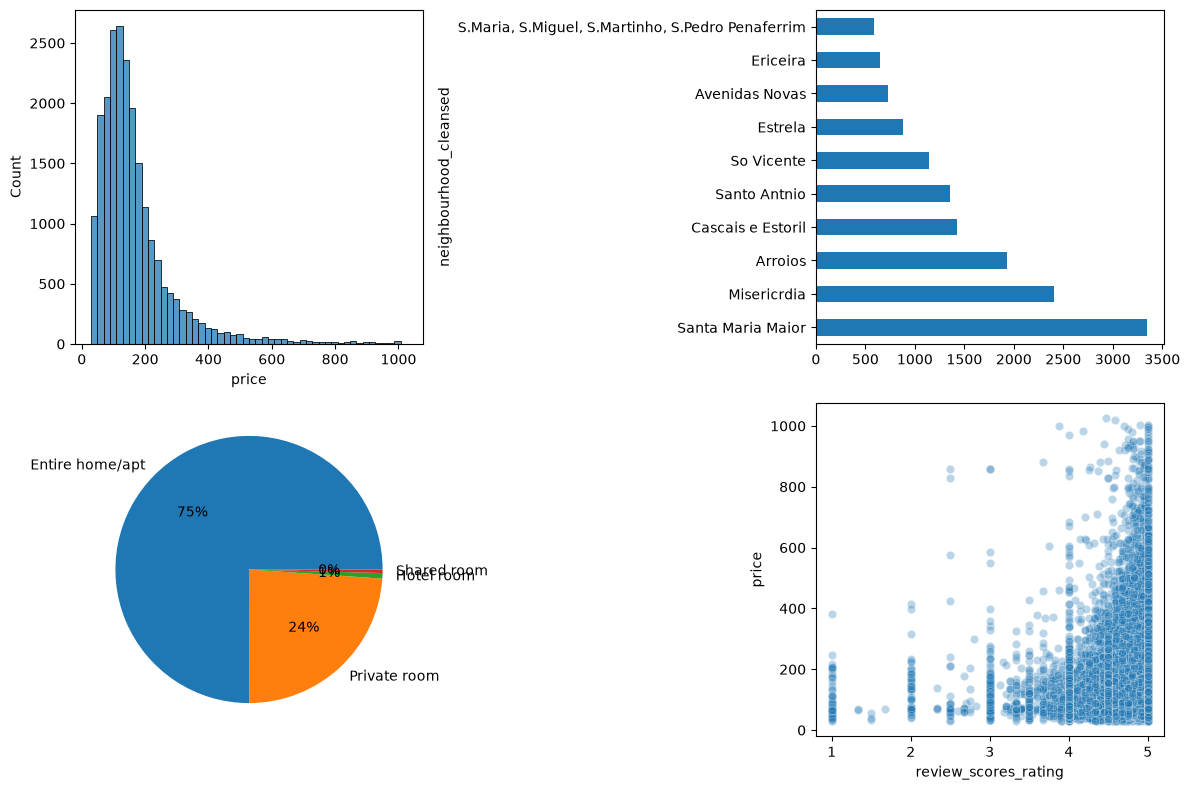

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(listings_clean['price'], bins=50, ax=axes[0,0])
listings_clean['neighbourhood_cleansed'].value_counts().head(10).plot.barh(ax=axes[0,1])
listings_clean['room_type'].value_counts().plot.pie(ax=axes[1,0], autopct='%1.0f%%')
sns.scatterplot(data=listings_clean, x='review_scores_rating', y='price', ax=axes[1,1],alpha=0.3)
plt.tight_layout()


C:\Users\aymen\AppData\Local\Temp\ipykernel_32236\427633050.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=room_shares.values, y=room_shares.index, ax=axes[1,0], palette='Blues_r')


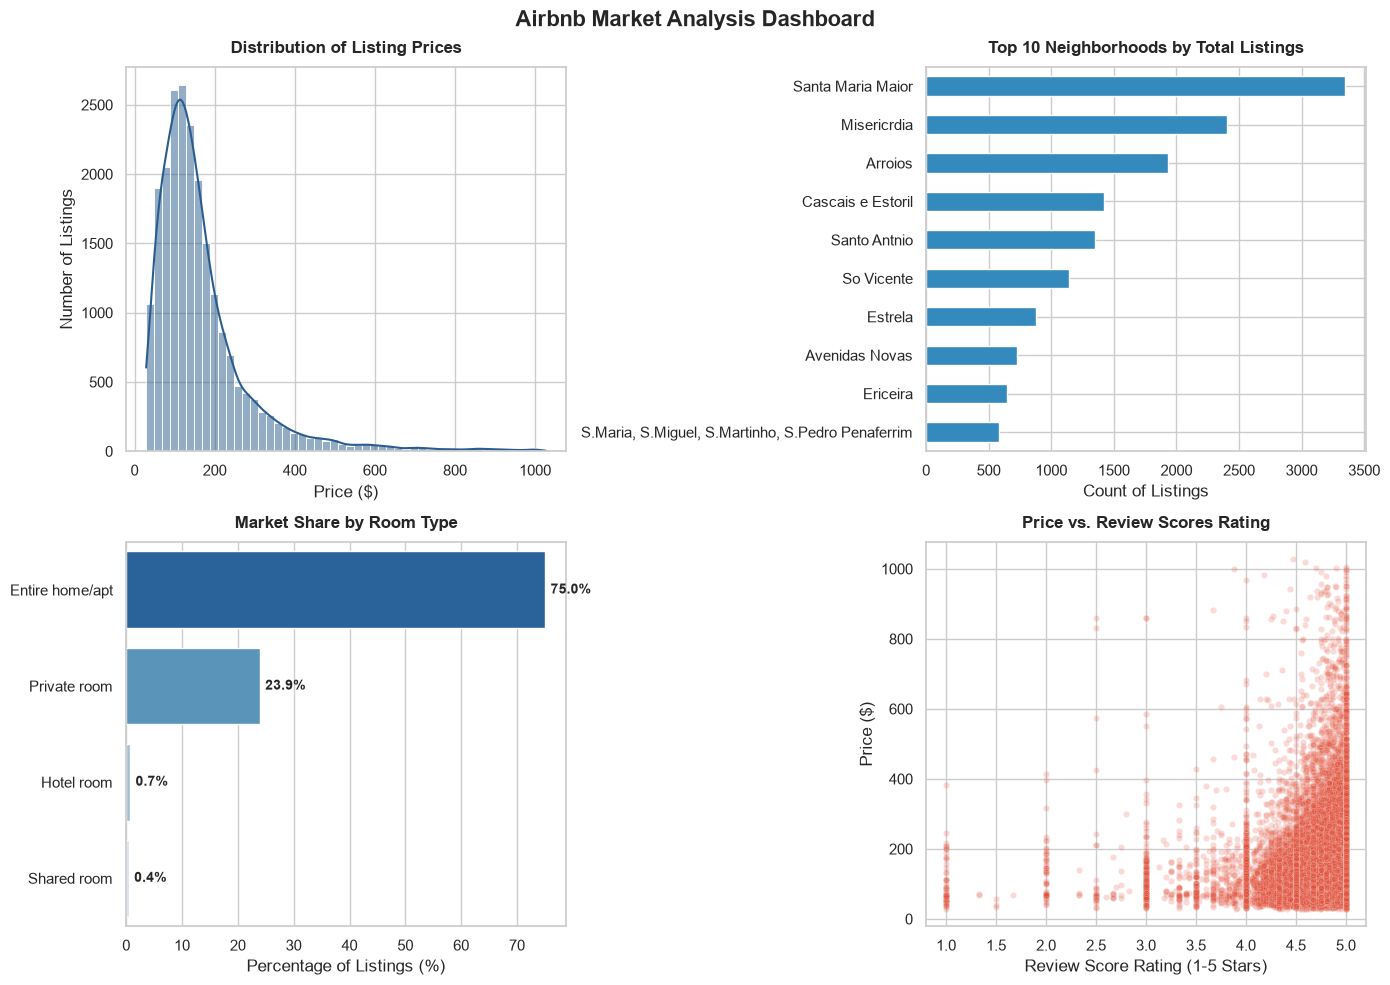

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a clean, professional aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})

# Initialize a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Top Left: Price Distribution (With Log Scale for skewed text/data)
sns.histplot(listings_clean['price'], bins=50, ax=axes[0,0], kde=True, color='#2b5c8f')
axes[0,0].set_title('Distribution of Listing Prices', fontsize=12, fontweight='bold', pad=10)
axes[0,0].set_xlabel('Price ($)')
axes[0,0].set_ylabel('Number of Listings')

# 2. Top Right: Top 10 Neighborhoods
# Note: Suggest replacing/shortening long names in listings_clean before this step
top_neighborhoods = listings_clean['neighbourhood_cleansed'].value_counts().head(10)
top_neighborhoods.plot.barh(ax=axes[0,1], color='#348abd')
axes[0,1].set_title('Top 10 Neighborhoods by Total Listings', fontsize=12, fontweight='bold', pad=10)
axes[0,1].set_xlabel('Count of Listings')
axes[0,1].set_ylabel('') # Removed redundant vertical title
axes[0,1].invert_yaxis()  # Puts the highest count neighborhood at the top

# 3. Bottom Left: Room Type Share (Converted to a clean horizontal bar)
room_shares = listings_clean['room_type'].value_counts(normalize=True) * 100
sns.barplot(x=room_shares.values, y=room_shares.index, ax=axes[1,0], palette='Blues_r')
axes[1,0].set_title('Market Share by Room Type', fontsize=12, fontweight='bold', pad=10)
axes[1,0].set_xlabel('Percentage of Listings (%)')
axes[1,0].set_ylabel('')
# Add clean percentage text labels next to the bars
for i, v in enumerate(room_shares.values):
    axes[1,0].text(v + 1, i, f"{v:.1f}%", va='center', fontweight='bold')

# 4. Bottom Right: Ratings vs Price (Alpha and size adjusted for text/plot layout)
sns.scatterplot(data=listings_clean, x='review_scores_rating', y='price', ax=axes[1,1], alpha=0.2, s=20, color='#e24a33')
axes[1,1].set_title('Price vs. Review Scores Rating', fontsize=12, fontweight='bold', pad=10)
axes[1,1].set_xlabel('Review Score Rating (1-5 Stars)')
axes[1,1].set_ylabel('Price ($)')

# Overall Layout Tuning
fig.suptitle('Airbnb Market Analysis Dashboard', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
